**SMITHI SURESHAN**

**M25MAC012**      
**Assignment2- Problem 1**

Importing Libraries

In [1]:
!pip install nltk wordcloud scikit-learn beautifulsoup4
import re
import nltk
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from wordcloud import WordCloud#it gives word cloud visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from nltk.corpus import stopwords
from collections import Counter#it counts frequency of word

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Uploading file

In [2]:
from google.colab import files
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

Saving corpus.txt to corpus.txt


Reading entire file

In [3]:
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()
text = BeautifulSoup(text, "html.parser").get_text()  # it removes html tags

Cleaning text

In [4]:
text = re.sub(r'http\S+|www\S+', ' ', text) #it removes URLs
text = re.sub(r'\bdot\b', ' ', text)
text = re.sub(r'\bcall\b', ' ', text)
# Common unwanted words
boilerplate = [
    "home","index","page","back","next","menu","search",
    "click","read","more","view",
    "iit","jodhpur","indian","institute",
    "department","program","course","semester",
    "application","admission","registration",
    "system","process","based","download file","http",
]
#it removes boiler word
for word in boilerplate:
    text = re.sub(rf'\b{word}\b', ' ', text, flags=re.IGNORECASE)

text = text.lower() #for converting into lowercase
text = re.sub(r'[^a-z\s]', ' ', text)#for removing numbers and symbols and keep only alphabets
text = re.sub(r'\s+', ' ', text).strip()#it removes extra spaces

Stopwords and tokenization

In [5]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
important_words = {"student","exam","phd","research"} # these are words which we need for our implementation
stop_words = stop_words - important_words #it removes important worrds from stop words
#adding unwanted words
stop_words.update([
    "call","page","home","back","index",
    "year","may","also","shall","include","download file"
])
#it breaks text into sentences
sentences_raw = nltk.sent_tokenize(text)

sentences = []
for raw_sent in sentences_raw:
    sent_tokens = nltk.word_tokenize(raw_sent)#it breaks sentences into words
    cleaned_sent_tokens = [w for w in sent_tokens if w not in stop_words and len(w) > 2]#it removes stopwords and very short words
    if cleaned_sent_tokens:
        sentences.append(cleaned_sent_tokens)

tokens = [w for s in sentences for w in s]#it flattens tokens list
freq = Counter(tokens)#it counts frequency of words

important_words = {
    "student","students","research","phd","exam",
    "thesis","masters","btech","mtech",
    "course","degree","engineering","science","data"
}
#it removes rarely appearing words
tokens = [w for w in tokens if freq[w] >= 3 or w in important_words]
freq = Counter(tokens)# it counts frequency

sentences = [[w for w in s if freq[w] >= 5] for s in sentences]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
print(freq)# print frequency

Counter({'lectures': 1366, 'engineering': 710, 'tech': 637, 'systems': 573, 'learning': 540, 'design': 490, 'data': 483, 'students': 465, 'science': 341, 'introduction': 307, 'edition': 300, 'research': 297, 'analysis': 296, 'applications': 280, 'offered': 258, 'student': 256, 'material': 235, 'elective': 234, 'type': 233, 'title': 226, 'techniques': 226, 'degree': 215, 'computer': 214, 'technology': 214, 'ability': 209, 'number': 207, 'outcomes': 207, 'objectives': 199, 'books': 195, 'algorithms': 194, 'principles': 193, 'courses': 192, 'contents': 192, 'academic': 185, 'control': 180, 'prerequisite': 175, 'drug': 174, 'reference': 169, 'problems': 168, 'energy': 168, 'biology': 168, 'development': 158, 'understanding': 154, 'computing': 154, 'materials': 154, 'flow': 153, 'physics': 150, 'structure': 150, 'cell': 150, 'self': 149, 'machine': 147, 'biological': 147, 'requirements': 145, 'methods': 144, 'computational': 143, 'heat': 142, 'dual': 139, 'networks': 138, 'instructor': 138,

Saving Clean corpus after preprocessing and Data Statistics

In [7]:
with open("clean_corpus.txt", "w") as f:
    for s in tokens:
        f.write(s + "\n")

print("Clean corpus saved")
vocab = list(set(tokens))# it creates vocabulary
print("\nSTATISTICS")
print("Total Documents:", len(sentences_raw))
print("Total Tokens:", len(tokens))
print("Vocabulary Size:", len(set(tokens)))

Clean corpus saved

STATISTICS
Total Documents: 1
Total Tokens: 61726
Vocabulary Size: 3479


Word Cloud

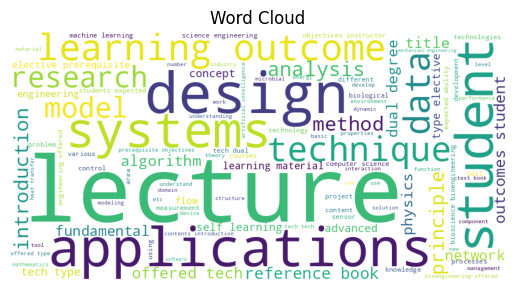

In [8]:
wc = WordCloud(width=900, height=450, background_color='white', max_words=100)
wc.generate(" ".join(tokens))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

Negative Sampling Distribution

In [9]:
pow_freq = np.array([freq[w]**0.75 for w in vocab])
neg_dist = pow_freq / pow_freq.sum()

In [10]:
vocab = list(set(tokens))#it creates word index mapping
word2idx = {w:i for i,w in enumerate(vocab)}# mapping word to index
idx2word = {i:w for w,i in word2idx.items()}#mapping index to word
#model parameters
vocab_size = len(vocab)
embedding_dim = 300
window = 5
#it generates training data for CBOW
def generate_cbow_data(sentences):
    data = []
    for sent in sentences:
        for i in range(window, len(sent)-window):
            context = [word2idx[sent[j]] for j in range(i-window, i+window+1) if j != i]
            target = word2idx[sent[i]]
            data.append((context, target))
    return data
#it generates training data for Skip Gram
def generate_skipgram_data(sentences):
    data = []
    for sent in sentences:
        for i, word in enumerate(sent):
            target = word2idx[word]
            for j in range(max(0, i-window), min(len(sent), i+window+1)):
                if j != i:
                    context = word2idx[sent[j]]
                    data.append((target, context))
    return data
#it prepares data for training
cbow_data = generate_cbow_data(sentences)
skip_data = generate_skipgram_data(sentences)
#initializing weight matrices
W1 = np.random.randn(vocab_size, embedding_dim)
W2 = np.random.randn(embedding_dim, vocab_size)
W1_s = np.random.randn(vocab_size, embedding_dim)
W2_s = np.random.randn(embedding_dim, vocab_size)

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def one_hot(i):
    vec = np.zeros(vocab_size)
    vec[i] = 1
    return vec


In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def cosine(a, b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

In [12]:
#initializing CBOW weights
W_target_c = np.random.randn(vocab_size, embedding_dim)
W_context_c = np.random.randn(vocab_size, embedding_dim)

Training for CBOW

In [13]:
#parameters for training
epochs = 10
lr = 0.01
neg_samples = 10
#CBOW loop for training
for epoch in range(epochs):
    loss = 0

    for context, target in cbow_data:

        v_c = np.mean([W_context_c[i] for i in context], axis=0)
        v_t = W_target_c[target]

        score = sigmoid(np.dot(v_t, v_c))
        loss += -np.log(score + 1e-9)

        grad = lr * (score - 1)

        W_target_c[target] -= grad * v_c
        for i in context:
            W_context_c[i] -= grad * v_t / len(context)
        neg_indices = np.random.choice(
    vocab_size, neg_samples, p=neg_dist, replace=False)

        for neg in neg_indices:
            v_n = W_target_c[neg]

            score_neg = sigmoid(np.dot(v_n, v_c))
            loss += -np.log(1 - score_neg + 1e-9)

            grad = lr * score_neg

            W_target_c[neg] -= grad * v_c
            for i in context:
                W_context_c[i] -= grad * v_n / len(context)

    print(f"CBOW Epoch {epoch+1}, Loss: {loss:.2f}")

CBOW Epoch 1, Loss: 1195862.81
CBOW Epoch 2, Loss: 682922.67
CBOW Epoch 3, Loss: 470987.13
CBOW Epoch 4, Loss: 373536.65
CBOW Epoch 5, Loss: 317282.52
CBOW Epoch 6, Loss: 274991.69
CBOW Epoch 7, Loss: 244287.36
CBOW Epoch 8, Loss: 219210.66
CBOW Epoch 9, Loss: 197194.96
CBOW Epoch 10, Loss: 180904.22


In [14]:
#Initializing Skip gram weights
embedding_dim = 300
W_target_s = np.random.randn(vocab_size, embedding_dim)
W_context_s = np.random.randn(vocab_size, embedding_dim)

Training for Skip Gram

In [15]:
#parameters for training
epochs = 10
lr = 0.01
neg_samples = 10
#Training loop for skip gram
for epoch in range(epochs):
    loss = 0

    for target, context in skip_data:

        v_t = W_target_s[target]
        v_c = W_context_s[context]

        score = sigmoid(np.dot(v_t, v_c))
        loss += -np.log(score + 1e-9)

        grad = lr * (score - 1)

        W_target_s[target] -= grad * v_c
        W_context_s[context] -= grad * v_t

        neg_indices = np.random.choice(
    vocab_size, neg_samples, p=neg_dist, replace=False)

        for neg in neg_indices:
            v_n = W_context_s[neg]

            score_neg = sigmoid(np.dot(v_t, v_n))
            loss += -np.log(1 - score_neg + 1e-9)

            grad = lr * score_neg

            W_target_s[target] -= grad * v_n
            W_context_s[neg] -= grad * v_t

    print(f"Skip-gram Epoch {epoch+1}, Loss: {loss:.2f}")

Skip-gram Epoch 1, Loss: 10558096.15
Skip-gram Epoch 2, Loss: 3613229.26
Skip-gram Epoch 3, Loss: 2509156.46
Skip-gram Epoch 4, Loss: 2007129.60
Skip-gram Epoch 5, Loss: 1721534.60
Skip-gram Epoch 6, Loss: 1539432.62
Skip-gram Epoch 7, Loss: 1419060.87
Skip-gram Epoch 8, Loss: 1334985.01
Skip-gram Epoch 9, Loss: 1273979.73
Skip-gram Epoch 10, Loss: 1232686.67


In [16]:
#Cosine Similarity
def cosine(a, b):#for getting cosine similarity between vectores
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
#it searches for nearest words
def nearest(word, W):
    if word not in word2idx:#it checks whether word exists in vocabulary
        print("Not found")
        return

    vec = W[word2idx[word]]#it gets vector of input
    sims = []#it stores similarity scores
#it compares all words available in vocabulary
    for w in vocab:
        if w != word:#it skips same word
            sims.append((w, cosine(vec, W[word2idx[w]])))#similarity score we got is stored

    sims = sorted(sims, key=lambda x: x[1], reverse=True)[:5]#it uses similarity for sortingg words to get top 5 words

    print(f"\nTop words for '{word}':")
    for w, s in sims:
        print(w, f"{s:.3f}")#it gives similarity upto 3 decimal places

def analogy(a, b, c, W):
    if a not in word2idx or b not in word2idx or c not in word2idx: #it checks whether all words exist
        print(f"Missing word in analogy: {a}, {b}, {c}")
        return

    vec = W[word2idx[b]] - W[word2idx[a]] + W[word2idx[c]]#vector=b-a+c

    sims = []# it stores similarity scores
    #it compares with all words
    for w in vocab:
        if w not in [a, b, c]:
            sims.append((w, cosine(vec, W[word2idx[w]])))
#it sorts and gets top 5 words
    sims = sorted(sims, key=lambda x: x[1], reverse=True)[:5]

    print(f"\n{a}:{b} :: {c}: ?")
    for w, s in sims:
        print(w, f"{s:.3f}")

Normalizing every vector and makes vector length =1

In [17]:
def normalize(W):
    return W / np.linalg.norm(W, axis=1, keepdims=True)#each vector is normalized row-wise
#Normalizing CBOW and Skip-gram embeddings
W_target_c = normalize(W_target_c)
W_target_s = normalize(W_target_s)

Prints Nearest words, similar words using CBOW embeddings and Skip gram embeddings, Testing Analogies

In [18]:
print("\n==CBOW ===")
#using CBOW embeddings for finding similar words
for w in ["research","student","phd","exam"]:
    nearest(w, W_target_c)
#using Skip-gram embeddings for finding similar words
print("\n==SKIP-GRAM===")
for w in ["research","student","phd","exam"]:
    nearest(w, W_target_s)

#testing analogy with CBOW
print("\n==ANALOGY (CBOW)===")
analogy("engineering", "technology", "science", W_target_c)
analogy("student", "research", "engineering", W_target_c)
analogy("data", "science", "engineering", W_target_c)

#testing analogy with skip-gram
print("\n==ANALOGY (SKIP-GRAM)===")
analogy("engineering", "technology", "science", W_target_s)
analogy("student", "research", "engineering", W_target_s)
analogy("data", "science", "engineering", W_target_s)




==CBOW ===

Top words for 'research':
resolution 0.209
layers 0.196
mining 0.189
interpretation 0.189
virtualization 0.187

Top words for 'student':
concentration 0.214
tumors 0.205
remote 0.194
tmle 0.192
product 0.188

Top words for 'phd':
winter 0.204
theoretical 0.203
tech 0.202
perspective 0.191
different 0.187

Top words for 'exam':
medical 0.191
degrees 0.189
unix 0.188
leading 0.187
graphical 0.185

==SKIP-GRAM===

Top words for 'research':
student 0.609
academic 0.574
work 0.562
students 0.556
courses 0.526

Top words for 'student':
requirements 0.668
academic 0.665
courses 0.635
students 0.616
research 0.609

Top words for 'phd':
curriculum 0.489
students 0.474
tech 0.472
dual 0.471
programs 0.440

Top words for 'exam':
students 0.325
academic 0.313
regulations 0.309
days 0.305
chemistry 0.304

==ANALOGY (CBOW)===

engineering:technology :: science: ?
possible 0.239
metagenomics 0.206
university 0.202
importance 0.202
reflections 0.195

student:research :: engineering: ?
tre

Visualization using PCA


CBOW Visualization


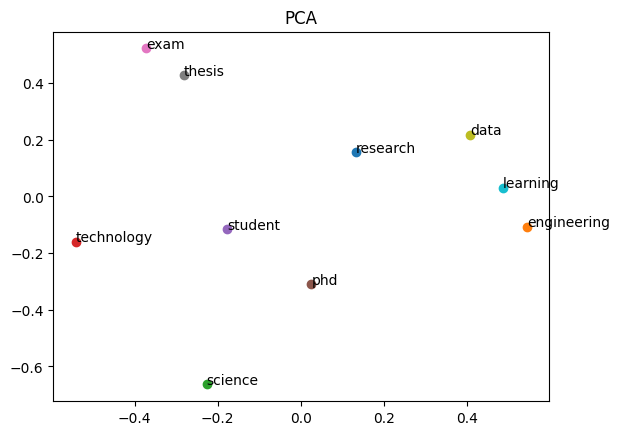


Skip-gram Visualization


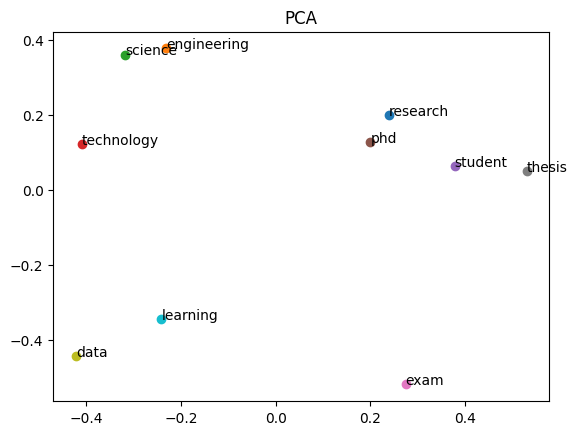

In [19]:
def visualize(W, words):
    vecs, labels = [], [] #it stores vectors and labels
#it collects vectors for given word
    for w in words:
        if w in word2idx:
            vecs.append(W[word2idx[w]])
            labels.append(w)

    vecs = np.array(vecs)# converting list to numpy array

    pca = PCA(n_components=2)#using PCA to reduce dimensions
    reduced = pca.fit_transform(vecs)
#Plotting  figure
    plt.figure()
    for i, word in enumerate(labels):
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0], reduced[i,1], word)
    plt.title("PCA")
    plt.show()
#words that we want to visualize
words = ["research","engineering","science","technology",
         "student","phd","exam","thesis","data","learning"]

print("\nCBOW Visualization")
visualize(W_target_c, words)

print("\nSkip-gram Visualization")
visualize(W_target_s, words)

In [37]:
word = "science"
idx = word2idx[word]
vector = W1[idx]
vector_300 = vector[:300]
print(word, "-", ", ".join([str(round(v,4)) for v in vector_300]))

science - -0.5055, 0.3757, 0.5226, -0.7901, -0.572, -0.5964, -0.7681, 0.4571, 1.8797, -1.201, -1.1979, 0.9853, -1.5225, -0.2941, -0.1374, 0.5995, -2.1133, -0.4743, -0.6035, 1.9319, 0.7227, 0.3579, 0.8042, -0.4424, 0.4598, 1.6624, 1.096, -0.8731, -1.4776, 0.6698, -0.0377, -1.2484, 0.9707, -0.6379, -0.4115, 0.299, 0.804, -2.3436, -0.0896, 0.0127, -0.8927, -0.7551, 1.9042, 0.7914, -0.9795, -1.292, -1.5874, -0.6125, 0.6336, -0.0655, -0.108, 0.0711, 0.5915, -1.8039, -0.0862, -0.2347, -0.1813, -1.8156, -1.452, -0.0477, -1.2445, -0.267, -0.8362, -0.3075, 0.6497, 0.4915, -0.5419, 0.5837, 1.7328, -1.2792, -1.3427, 0.9801, -1.1023, -0.0293, -0.5867, -0.1049, -0.0173, -0.1578, 0.8979, -0.2281, -1.7395, 0.2506, 0.1633, 0.4303, 0.5157, 1.1682, -0.142, -0.7914, 0.8884, -0.4235, 0.6227, -0.789, -1.3837, -1.2072, 0.1185, -1.3994, -1.0814, -0.713, -0.1257, 0.6258, -2.0368, -0.6084, 0.0888, 1.4697, -0.6079, -0.5827, -0.6712, 1.4642, -0.5161, -1.953, -0.1373, 0.5603, -2.0607, 0.564, -1.1823, 0.4478, -1.4

---------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

By using Built-in libraries for comparison

Importing Libraries

In [22]:
!pip install gensim nltk wordcloud scikit-learn beautifulsoup4
import re
import nltk
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from nltk.corpus import stopwords
from collections import Counter
nltk.download('punkt')  #it is for sentence tokenization
nltk.download('stopwords') #it is for removing common words

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Uploading file

In [23]:
from google.colab import files
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

Saving corpus.txt to corpus (1).txt


Reading Entire file

In [24]:
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

Text Cleaning

In [25]:
text = BeautifulSoup(text, "html.parser").get_text()#it removes HTML tags
text = re.sub(r'http\S+|www\S+', ' ', text)#it removes URL
text = re.sub(r'\bdot\b', ' ', text)
text = re.sub(r'\bcall\b', ' ', text)
#Common words in websites
boilerplate = [
    "home","index","page","back","next","menu","search",
    "click","read","more","view",
    "iit","jodhpur","indian","institute",
    "department","program","course","semester",
    "application","admission","registration",
    "system","process","based","download file"
]
#it removes unwanted words
for word in boilerplate:
    text = re.sub(rf'\b{word}\b', ' ', text, flags=re.IGNORECASE)

In [26]:
text = text.lower()#it converts text to lowercase
text = re.sub(r'[^a-z\s]', ' ', text) #it removes numbers and symbols and keep only alphabets
text = re.sub(r'\s+', ' ', text).strip()# it removes extra spaces

In [27]:
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
important_words = {"student","exam","phd","research"}
stop_words = stop_words - important_words#it removes important words from stopwords

stop_words.update(
    ["call","page","home","back","index",
    "year","may","also","shall","include","download file"]
)
#Tokenization
sentences = nltk.sent_tokenize(text)#splitting text into sentences
tokenized = []
for sent in sentences:
    words = nltk.word_tokenize(sent) #splitting sentence into words
    words = [w for w in words if w not in stop_words and len(w) > 2]# it removes stopwords and very short words and keep meaningful sentences
    if words:
        tokenized.append(words)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [28]:
tokens = [w for s in tokenized for w in s]#flatten all words into one list
freq = Counter(tokens)#it count frequency of each word
sentences = [[w for w in s if freq[w] < 500] for s in tokenized if len(s) > 0]#it removes words which come frequently

In [29]:
print(freq)#it prinyts frequency of words

Counter({'lectures': 1366, 'engineering': 710, 'tech': 637, 'systems': 573, 'learning': 540, 'design': 490, 'data': 483, 'students': 465, 'science': 341, 'introduction': 307, 'edition': 300, 'research': 297, 'analysis': 296, 'applications': 280, 'offered': 258, 'student': 256, 'material': 235, 'elective': 234, 'type': 233, 'title': 226, 'techniques': 226, 'degree': 215, 'computer': 214, 'technology': 214, 'ability': 209, 'number': 207, 'outcomes': 207, 'objectives': 199, 'books': 195, 'algorithms': 194, 'principles': 193, 'courses': 192, 'contents': 192, 'academic': 185, 'control': 180, 'prerequisite': 175, 'drug': 174, 'reference': 169, 'problems': 168, 'energy': 168, 'biology': 168, 'development': 158, 'understanding': 154, 'computing': 154, 'materials': 154, 'flow': 153, 'physics': 150, 'structure': 150, 'cell': 150, 'self': 149, 'machine': 147, 'biological': 147, 'requirements': 145, 'methods': 144, 'computational': 143, 'heat': 142, 'dual': 139, 'networks': 138, 'instructor': 138,

Saving clean corpus

In [30]:
with open("clean_corpus.txt", "w") as f:
    for s in sentences:
        f.write(" ".join(s) + "\n")

print("Clean corpus saved")

Clean corpus saved


Total Documents, tokens, Vocabulary Size

In [31]:
tokens = [w for s in sentences for w in s]#again calculating tokens after filtering
print("\nSTATISTICS")
print("Total Documents:", len(sentences))
print("Total Tokens:", len(tokens))
print("Vocabulary Size:", len(set(tokens)))


STATISTICS
Total Documents: 1
Total Tokens: 64715
Vocabulary Size: 8850


Word Cloud

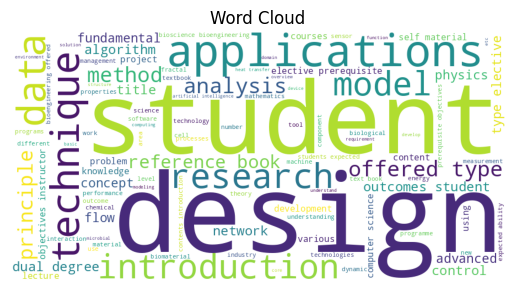

In [32]:
wc = WordCloud(
    width=900,
    height=450,
    background_color='white',
    max_words=100
).generate(" ".join(tokens))

plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

Training Multiple Models

In [33]:
#various configurations for testing model performance
configs = [
    {"vector_size":50, "window":3, "negative":3},
    {"vector_size":100, "window":5, "negative":5},
    {"vector_size":200, "window":7, "negative":10}
]

models = []
#training model with different settings
for config in configs:
    print("\nTraining config:", config)
#CBOW model
    cbow = Word2Vec(
        sentences,
        vector_size=config["vector_size"],
        window=config["window"],
        negative=config["negative"],
        min_count=2,
        sg=0,
        epochs=100
    )
#Skip gram model
    skip = Word2Vec(
        sentences,
        vector_size=config["vector_size"],
        window=config["window"],
        negative=config["negative"],
        min_count=2,
        sg=1,
        epochs=100
    )

    models.append((config, cbow, skip))

config, cbow_model, skip_model = models[1]


Training config: {'vector_size': 50, 'window': 3, 'negative': 3}

Training config: {'vector_size': 100, 'window': 5, 'negative': 5}

Training config: {'vector_size': 200, 'window': 7, 'negative': 10}


Finding nearest top 5 words

In [34]:
#it finds similar words
def nearest(model, word):
    print(f"\nTop 5 for '{word}':")
    if word in model.wv:
        for w,s in model.wv.most_similar(word, topn=5):
            print(w, f"{s:.3f}")
    else:
        print("Not in vocab")
#using CBOW for finding similar words
print("\n===== CBOW =====")
for w in ["research","student","phd","exam"]:
    nearest(cbow_model, w)
#using Skip gram for finding similar words
print("\n===== SKIP-GRAM =====")
for w in ["research","student","phd","exam"]:
    nearest(skip_model, w)


===== CBOW =====

Top 5 for 'research':
profile 0.776
quality 0.769
interest 0.755
members 0.748
academics 0.748

Top 5 for 'student':
continuation 0.947
waived 0.931
qualifier 0.929
fee 0.925
fees 0.923

Top 5 for 'phd':
waived 0.928
wherever 0.916
fees 0.913
arising 0.912
covered 0.906

Top 5 for 'exam':
comprehensive 0.980
attend 0.870
papers 0.857
weekends 0.856
regulations 0.850

===== SKIP-GRAM =====

Top 5 for 'research':
themes 0.563
labs 0.531
overview 0.513
academics 0.510
idrps 0.508

Top 5 for 'student':
continuation 0.737
residency 0.719
qualifier 0.709
completing 0.703
fees 0.696

Top 5 for 'phd':
arising 0.726
benefit 0.708
graduation 0.704
waived 0.702
par 0.700

Top 5 for 'exam':
comprehensive 0.903
seminar 0.870
syllabus 0.818
waitlisted 0.793
works 0.787


Analogies and testing various analogies

In [35]:
def analogy(model, a, b, c):
    print(f"\n{a}:{b} :: {c}: ?")
    try:
        result = model.wv.most_similar(positive=[b,c], negative=[a], topn=3)
        for w,s in result:
            print(w, f"{s:.3f}")
    except:
        print("Words missing")
#testing various analogies using cbow
print("\n===== ANALOGIES (CBOW) =====")
analogy(cbow_model, "engineering", "technology", "science")
analogy(cbow_model, "student", "research", "engineering")
analogy(cbow_model, "data", "science", "engineering")
#testing analogies using skip gram
print("\n===== ANALOGIES (SKIP-GRAM) =====")
analogy(skip_model, "engineering", "technology", "science")
analogy(skip_model, "student", "research", "engineering")
analogy(skip_model, "data", "science", "engineering")


===== ANALOGIES (CBOW) =====

engineering:technology :: science: ?
Words missing

student:research :: engineering: ?
Words missing

data:science :: engineering: ?
Words missing

===== ANALOGIES (SKIP-GRAM) =====

engineering:technology :: science: ?
Words missing

student:research :: engineering: ?
Words missing

data:science :: engineering: ?
Words missing


Visualizing using PCA and t-SNE


CBOW Visualization
Using 14 words for visualization


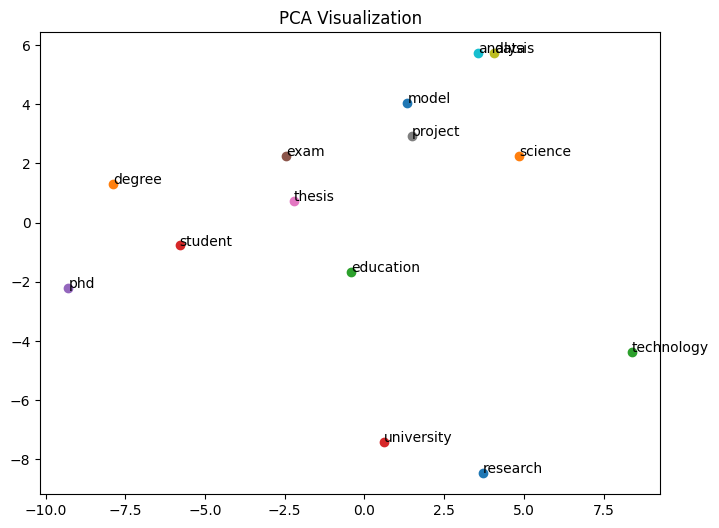

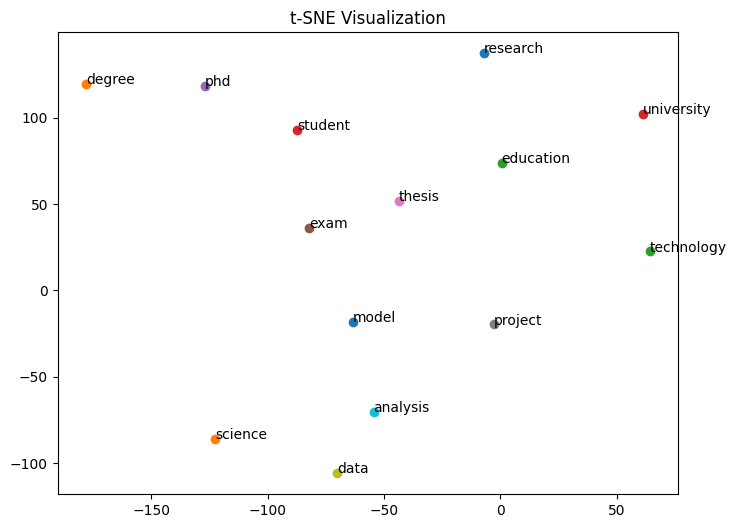


Skip-gram Visualization
Using 14 words for visualization


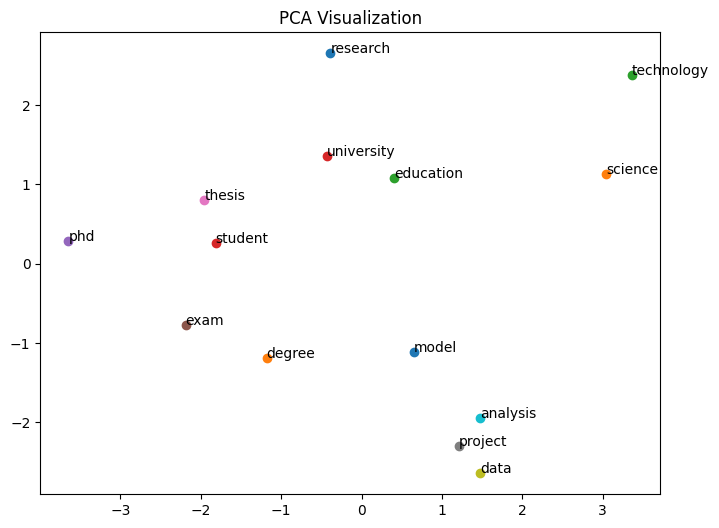

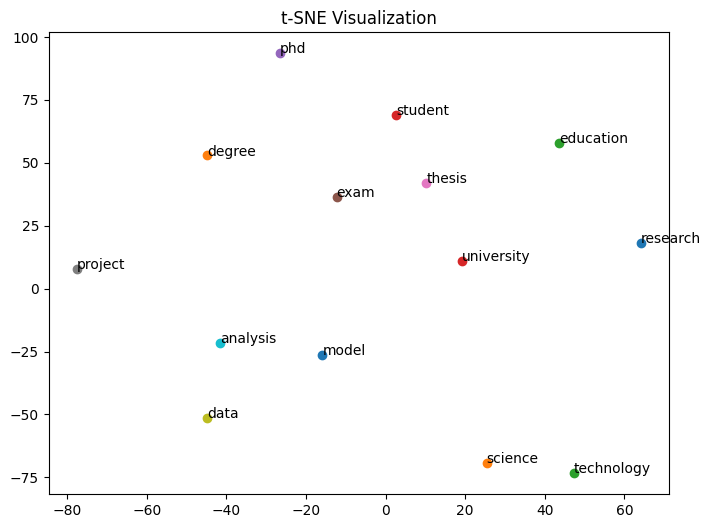

In [36]:
def visualize(model, words):
    vecs, labels = [], []
#collecting vectors of given worrds
    for w in words:
        if w in model.wv:
            vecs.append(model.wv[w])
            labels.append(w)

    print(f"Using {len(labels)} words for visualization")

    vecs_array = np.array(vecs)

    pca = PCA(n_components=2)#using PCA to reduce dimensions
    reduced = pca.fit_transform(vecs_array)

    plt.figure(figsize=(8,6))
    for i, word in enumerate(labels):
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0], reduced[i,1], word)

    plt.title("PCA Visualization")
    plt.show()
#Using t-SNE
    if len(vecs_array) > 10:
        tsne = TSNE(n_components=2, perplexity=5, random_state=42)
        reduced = tsne.fit_transform(vecs_array)

        plt.figure(figsize=(8,6))
        for i, word in enumerate(labels):
            plt.scatter(reduced[i,0], reduced[i,1])
            plt.text(reduced[i,0], reduced[i,1], word)

        plt.title("t-SNE Visualization")
        plt.show()
    else:
        print("Not enough words for t-SNE")
#words for visualizing
words = [
    "research","engineering","science","technology",
    "student","phd","exam","thesis","project",
    "data","analysis","learning","model",
    "course","degree","education","university"
]

print("\nCBOW Visualization")
visualize(cbow_model, words)

print("\nSkip-gram Visualization")
visualize(skip_model, words)